## Quetion 5/6 appendix

Shortest Path calculation for all cities as it requires it for 

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os


connectivity_df = pd.read_csv("../Processed_Data/connectivity.csv")
connectivity_df

,origin_city,destination_city,air_origin_airport,air_destination_airport,air_distance_km,air_flight_duration_min,air_total_travel_time_min,air_overhead_min,origin_city_lat,origin_city_lng,destination_city_lat,destination_city_lng,rail_origin_station_name,rail_destination_station_name,rail_travel_time_mins,rail_uses_hsr,rail_origin_transit_time_mins,rail_destination_transit_time_mins,rail_total_travel_time_min,best_time_min
0,Amsterdam,Antwerp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Amsterdam Centraal,Antwerpen Centraal,80.0,False,1.952034,3.528436,95.480470,95.480470
1,Amsterdam,Athens,AMS,ATH,2184.0,195.0,361.81,166.81,52.3728,4.8936,37.9842,23.7281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,361.810000
2,Amsterdam,Barcelona,AMS,BCN,1240.0,135.0,290.36,155.36,52.3728,4.8936,41.3828,2.1769,Amsterdam Centraal,Barcelona Sants,673.0,False,1.952034,7.388094,692.340128,290.360000
3,Amsterdam,Berlin,AMS,BER,595.0,80.0,244.46,164.46,52.3728,4.8936,52.5200,13.4050,Amsterdam Centraal,Berlin Hbf,342.0,False,1.952034,5.947266,359.899300,244.460000
4,Amsterdam,Bordeaux,AMS,BOD,923.0,100.0,251.53,151.53,52.3728,4.8936,44.8400,-0.5800,Amsterdam Centraal,Bordeaux-St-Jean,418.0,True,1.952034,5.811588,435.763622,251.530000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2565,Zagreb,Wrocław,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zagreb Glavni kolodvor,Wroclaw Glowny,836.0,False,2.322429,3.273168,851.595597,851.595597
2566,Zaragoza,Brussels,ZAZ,CRL,1064.0,120.0,321.16,201.16,41.6500,-0.8833,50.8467,4.3525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,321.160000
2567,Zaragoza,Bucharest,ZAZ,OTP,2217.0,205.0,363.99,158.99,41.6500,-0.8833,44.4325,26.1039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,363.990000
2568,Zaragoza,Milan,ZAZ,BGY,970.0,110.0,313.64,203.64,41.6500,-0.8833,45.4669,9.1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,313.640000


Aim of this analysis into organise existing dataframe which will be suitable into creating a graph representation, calcluate for each pair of cities min duration of shortest path.

In [4]:
air_columns = connectivity_df.columns[connectivity_df.columns.str.contains("air")]
rail_columns = connectivity_df.columns[connectivity_df.columns.str.contains("rail")]
air_columns

Index(['air_origin_airport', 'air_destination_airport', 'air_distance_km',
       'air_flight_duration_min', 'air_total_travel_time_min',
       'air_overhead_min'],
      dtype='object')

In [16]:
idx_air_columns = ["origin_city","destination_city"] + air_columns.tolist()
idx_rail_columns = ["origin_city","destination_city"] + rail_columns.tolist()
air_df = connectivity_df.loc[:, idx_air_columns]
rail_df = connectivity_df.loc[:, idx_rail_columns]
air_df = air_df.dropna(subset=air_columns, how="all")
rail_df = rail_df.dropna(subset=rail_columns, how="all")
rail_df.columns

Index(['origin_city', 'destination_city', 'rail_origin_station_name',
       'rail_destination_station_name', 'rail_travel_time_mins',
       'rail_uses_hsr', 'rail_origin_transit_time_mins',
       'rail_destination_transit_time_mins', 'rail_total_travel_time_min'],
      dtype='object')

In [15]:
air_df.columns

Index(['origin_city', 'destination_city', 'air_origin_airport',
       'air_destination_airport', 'air_distance_km', 'air_flight_duration_min',
       'air_total_travel_time_min', 'air_overhead_min'],
      dtype='object')

In [17]:
rail_df["type"] = "rail"
air_df["type"] = "air"

rail_df.rename(columns={col: col.replace("rail_", "") for col in rail_columns}, inplace=True)
air_df.rename(columns={col: col.replace("air_", "") for col in air_columns}, inplace=True)

rail_df.head()

,origin_city,destination_city,origin_station_name,destination_station_name,travel_time_mins,uses_hsr,origin_transit_time_mins,destination_transit_time_mins,total_travel_time_min,type
0,Amsterdam,Antwerp,Amsterdam Centraal,Antwerpen Centraal,80.0,False,1.952034,3.528436,95.480470,rail
2,Amsterdam,Barcelona,Amsterdam Centraal,Barcelona Sants,673.0,False,1.952034,7.388094,692.340128,rail
3,Amsterdam,Berlin,Amsterdam Centraal,Berlin Hbf,342.0,False,1.952034,5.947266,359.899300,rail
4,Amsterdam,Bordeaux,Amsterdam Centraal,Bordeaux-St-Jean,418.0,True,1.952034,5.811588,435.763622,rail
5,Amsterdam,Bratislava,Amsterdam Centraal,Bratislava hl.st.,761.0,False,1.952034,4.046858,776.998892,rail


In [18]:
air_df

,origin_city,destination_city,origin_airport,destination_airport,distance_km,flight_duration_min,total_travel_time_min,overhead_min,type
1,Amsterdam,Athens,AMS,ATH,2184.0,195.0,361.81,166.81,air
2,Amsterdam,Barcelona,AMS,BCN,1240.0,135.0,290.36,155.36,air
3,Amsterdam,Berlin,AMS,BER,595.0,80.0,244.46,164.46,air
4,Amsterdam,Bordeaux,AMS,BOD,923.0,100.0,251.53,151.53,air
6,Amsterdam,Bremen,AMS,BRE,284.0,55.0,196.39,141.39,air
...,...,...,...,...,...,...,...,...,...
2564,Zagreb,Warsaw,ZAG,WAW,800.0,95.0,242.11,147.11,air
2566,Zaragoza,Brussels,ZAZ,CRL,1064.0,120.0,321.16,201.16,air
2567,Zaragoza,Bucharest,ZAZ,OTP,2217.0,205.0,363.99,158.99,air
2568,Zaragoza,Milan,ZAZ,BGY,970.0,110.0,313.64,203.64,air


In [26]:
air_df.rename(columns={ "total_travel_time_min" :"gross_time","flight_duration_min":"net_time"}, inplace=True)
rail_df.rename(columns={"total_travel_time_min":"gross_time", "travel_time_mins":"net_time"}, inplace=True)

rail_df_filtered = rail_df.loc[:, ["origin_city", "destination_city", "gross_time", "net_time", "type"]]
air_df_filtered = air_df.loc[:, ["origin_city", "destination_city", "gross_time", "net_time", "type"]]

combined_df = pd.concat([air_df.loc[:, ["origin_city", "destination_city", "gross_time", "net_time", "type"]], rail_df.loc[:, ["origin_city", "destination_city", "gross_time", "net_time", "type"]]], ignore_index=True)
combined_df.to_csv("../Processed_Data/combined_transport_times.csv", index=False)
combined_df

,origin_city,destination_city,gross_time,net_time,type
0,Amsterdam,Athens,361.810000,195.0,air
1,Amsterdam,Barcelona,290.360000,135.0,air
2,Amsterdam,Berlin,244.460000,80.0,air
3,Amsterdam,Bordeaux,251.530000,100.0,air
4,Amsterdam,Bremen,196.390000,55.0,air
...,...,...,...,...,...
3209,Zagreb,Toulouse,1455.984210,1441.0,rail
3210,Zagreb,Turin,884.170030,869.0,rail
3211,Zagreb,Vienna,411.567642,393.0,rail
3212,Zagreb,Warsaw,1163.643683,1150.0,rail


In [ ]:
import itertools

def create_transport_graph(df):
    """
    Creates a state-augmented directed graph based on transport logic.
    """
    G = nx.DiGraph()
    
    # Iterate through every row to build edges
    for index, row in df.iterrows():
        u = row['origin_city']
        v = row['destination_city']
        t = row['type']  # 'air' or 'rail'
        g_time = row['gross_time']
        n_time = row['net_time']
        
        # Define node names based on state
        # Source is abstract, others are specific to arrival mode
        u_src = f"{u}_SRC"
        
        v_air = f"{v}_air"
        v_rail = f"{v}_rail"
        
        u_air = f"{u}_air"
        u_rail = f"{u}_rail"
        current_dest_node = v_air if t == 'air' else v_rail
        
        # For given two cities i add all possible edges according to the logic
        G.add_edge(u_src, current_dest_node, weight=g_time, label=f"Start->{t}")
        if t == 'air':
            G.add_edge(u_air, current_dest_node, weight=n_time, label="Air->Air")
        else: 
            G.add_edge(u_rail, current_dest_node, weight=n_time, label="Rail->Rail")
        if t == 'air':
            G.add_edge(u_rail, current_dest_node, weight=g_time, label="Rail->Air")
        else:
            G.add_edge(u_air, current_dest_node, weight=g_time, label="Air->Rail")
            
    return G

def calculate_shortest_paths(df):
    G = create_transport_graph(df)
    cities = pd.concat([df['origin_city'], df['destination_city']]).unique()
    
    # Create a lookup for direct routes to handle the rouets unless direct one exists
    direct_routes = {}
    for idx, row in df.iterrows():
        pair = (row['origin_city'], row['destination_city'])
        if pair not in direct_routes:
            direct_routes[pair] = row['gross_time']
        else:
            # If more direct routes exist, take faster one
            direct_routes[pair] = min(direct_routes[pair], row['gross_time'])

    results = []

    # Iterate over all pairs of nodes
    for origin, destination in itertools.permutations(cities, 2):
        path_type = "Indirect"
        shortest_time = float('inf')
        path_nodes = []

        if (origin, destination) in direct_routes:
            shortest_time = direct_routes[(origin, destination)]
            path_type = "Direct"
            path_nodes = [origin, destination]
        else:
            # -- CALCULATE: Shortest Path via Graph --
            source_node = f"{origin}_SRC"
            target_nodes = [f"{destination}_air", f"{destination}_rail"]
            found_path = False
            
            for target in target_nodes:
                if G.has_node(source_node) and G.has_node(target):
                    try:
                        length = nx.shortest_path_length(G, source=source_node, target=target, weight='weight')
                        if length < shortest_time:
                            shortest_time = length
                            raw_path = nx.shortest_path(G, source=source_node, target=target, weight='weight')
                            path_nodes = [n.split('_')[0] for n in raw_path]
                            found_path = True
                    except nx.NetworkXNoPath:
                        continue
            
            if not found_path:
                shortest_time = None
                path_nodes = []

        results.append({
            'origin': origin,
            'destination': destination,
            'total_time': shortest_time,
            'route_type': path_type,
            'path': " -> ".join(path_nodes) if path_nodes else "No Route"
        })

    return pd.DataFrame(results)

transport_graph = create_transport_graph(combined_df)
shortest_paths_df = calculate_shortest_paths(combined_df)
shortest_paths_df[shortest_paths_df["route_type"] == "Indirect"]

,origin,destination,total_time,route_type,path
10,Amsterdam,Cologne,240.201260,Indirect,Amsterdam -> Rotterdam -> Antwerp -> Cologne
53,Amsterdam,Zaragoza,318.170000,Indirect,Amsterdam -> Brussels -> Zaragoza
58,Antwerp,Athens,396.640129,Indirect,Antwerp -> Brussels -> Athens
65,Antwerp,Bucharest,370.180129,Indirect,Antwerp -> Brussels -> Bucharest
74,Antwerp,Gothenburg,316.810129,Indirect,Antwerp -> Brussels -> Gothenburg
...,...,...,...,...,...
3291,Wrocław,Sofia,412.628603,Indirect,Wrocław -> Poznań -> Warsaw -> Sofia
3294,Wrocław,Tallinn,397.628603,Indirect,Wrocław -> Poznań -> Warsaw -> Tallinn
3298,Wrocław,Valencia,468.888603,Indirect,Wrocław -> Poznań -> Prague -> Valencia
3300,Wrocław,Vilnius,357.628603,Indirect,Wrocław -> Poznań -> Warsaw -> Vilnius


Using current connection find best and worst city by connectivity. For this i use closeness measure 
which is defined as follows:

$$  C_B(x) =\frac{1}{\sum_{y}{d(y,x)}}$$

Closeness is the measure which explains how fast i can get from given nodes to all others. Here as the distance if two given nodes are not directly connected i use shortest path.

In [ ]:
def analyze_network_centrality(shortest_paths_df):
    G = nx.DiGraph()
    
    # Add edges with calculated travel times as weights
    # Filter out self-loops or NaNs
    clean_df = shortest_paths_df.dropna(subset=['total_time'])

    for _, row in clean_df.iterrows():
        G.add_edge(row['origin'], row['destination'], weight=row['total_time'])
        
    # Compute Closeness Centrality
    centrality = nx.closeness_centrality(G, distance='weight')
    
    # Convert to DataFrame
    centrality_df = pd.DataFrame(list(centrality.items()), columns=['city', 'centrality'])
    centrality_df = centrality_df.sort_values(by='centrality', ascending=False).reset_index(drop=True)
    
    return G, centrality_df

centrality_graph, centrality_df = analyze_network_centrality(shortest_paths_df)
centrality_df.sort_values(by='centrality', ascending=False).head(10)

,city,centrality
0,Düsseldorf,0.004049
1,Frankfurt,0.004009
2,Amsterdam,0.003804
3,Brussels,0.003737
4,Essen,0.003656
5,Berlin,0.003655
6,Stuttgart,0.003596
7,Munich,0.003595
8,Copenhagen,0.003576
9,Duisburg,0.003567


In [37]:
centrality_df.sort_values(by='centrality', ascending=True).head(10)

,city,centrality
57,Wrocław,0.002491
56,Zaragoza,0.002632
55,Lisbon,0.002763
54,Stockholm,0.002771
53,Sevilla,0.002777
52,Ljubljana,0.002782
51,Bordeaux,0.002877
50,Málaga,0.002881
49,Athens,0.002890
48,Genoa,0.002893


Visualise some of cities connectivity with isochrones

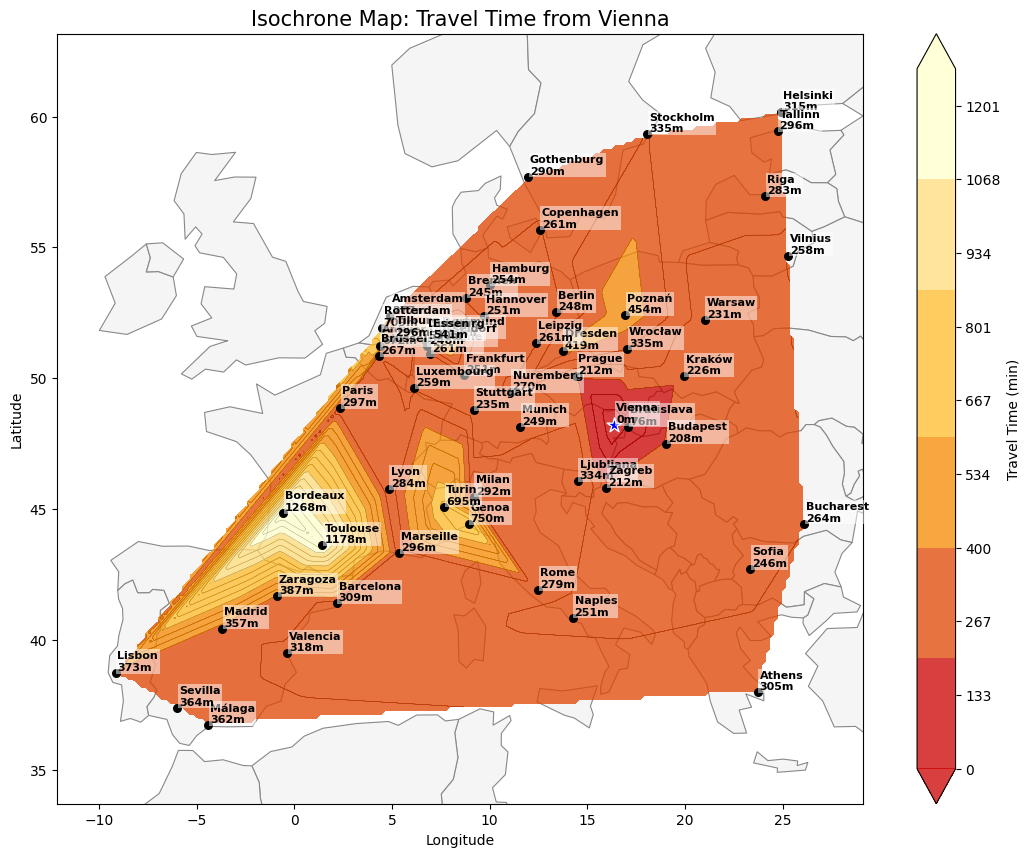

In [72]:
import plotly.graph_objects as go
from scipy.interpolate import griddata
import matplotlib.colors as mcolors


cities_coords_df = pd.read_csv("../Processed_Data/cities_coordinates.csv")

def visualize_isochrones(start_city, G, coords_df):
    """
    Visualizes travel time isochrones using Matplotlib and Geopandas.
    Fetches country boundaries from Natural Earth URL.
    """
    times = {}

    if len(list(G.neighbors(start_city))) > 0:
        for node in G.neighbors(start_city):
                times[node] = G[start_city][node]['weight']
    times[start_city] = 0 

    plot_data = []
    for city, t in times.items():
        row = coords_df[coords_df['city'] == city]
        if not row.empty:
            plot_data.append({
                'city': city,
                'time': t,
                'lat': row.iloc[0]['lat'],
                'lon': row.iloc[0]['lon']
            })

    df_plot = pd.DataFrame(plot_data)

    if df_plot.empty:
        print("No data points found to plot.")
        return

    pad = 3.0
    x_min, x_max = df_plot['lon'].min() - pad, df_plot['lon'].max() + pad
    y_min, y_max = df_plot['lat'].min() - pad, df_plot['lat'].max() + pad

    grid_x, grid_y = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]

    grid_z = griddata(
        (df_plot['lon'], df_plot['lat']), 
        df_plot['time'], 
        (grid_x, grid_y), 
        method='linear'
    )

    shapefile_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    try:
        world = gpd.read_file(shapefile_url)
    except Exception as e:
        print(f"Could not download map data: {e}")
        return


    colors = ["#cc0000", "#ffaa00", "#ffffcc"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("RedToLightYellow", colors, N=6)

    # 6. Plotting
    fig, ax = plt.subplots(figsize=(14, 10))


    world.cx[x_min:x_max, y_min:y_max].plot(
        ax=ax, 
        color='whitesmoke', 
        edgecolor='#888888', 
        linewidth=0.8,
        zorder=1
    )

    levels = np.linspace(0, df_plot['time'].max(), 20)

    contour = ax.contourf(
        grid_x, grid_y, grid_z, 
        levels=levels, 
        cmap=custom_cmap, 
        alpha=0.75, # Transparency
        zorder=2,
        extend='both'
    )

    cbar = plt.colorbar(contour, ax=ax, label='Travel Time (min)')

    ax.contour(
        grid_x, grid_y, grid_z, 
        levels=levels, 
        colors='black', 
        linewidths=0.3, 
        alpha=0.4, 
        zorder=3
    )

    ax.scatter(df_plot['lon'], df_plot['lat'], c='black', s=30, zorder=4)

    start_row = df_plot[df_plot['city'] == start_city].iloc[0]
    ax.scatter(
        start_row['lon'], start_row['lat'], 
        c='blue', s=120, marker='*', 
        edgecolors='white', zorder=5, label='Origin'
    )

    for _, row in df_plot.iterrows():
        # Only label if within bounds
        if x_min < row['lon'] < x_max and y_min < row['lat'] < y_max:
            ax.text(
                row['lon'] + 0.1, row['lat'] + 0.1, 
                f"{row['city']}\n{int(row['time'])}m", 
                fontsize=8, weight='bold', zorder=6,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
            )

    ax.set_title(f"Isochrone Map: Travel Time from {start_city}", fontsize=15)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    plt.show()

cities_coords_df.rename(columns={"name_city":"city","lat_city":"lat","lng_city":"lon"}, inplace=True)
cities_coords_df.head()
visualize_isochrones("Vienna", centrality_graph, cities_coords_df)


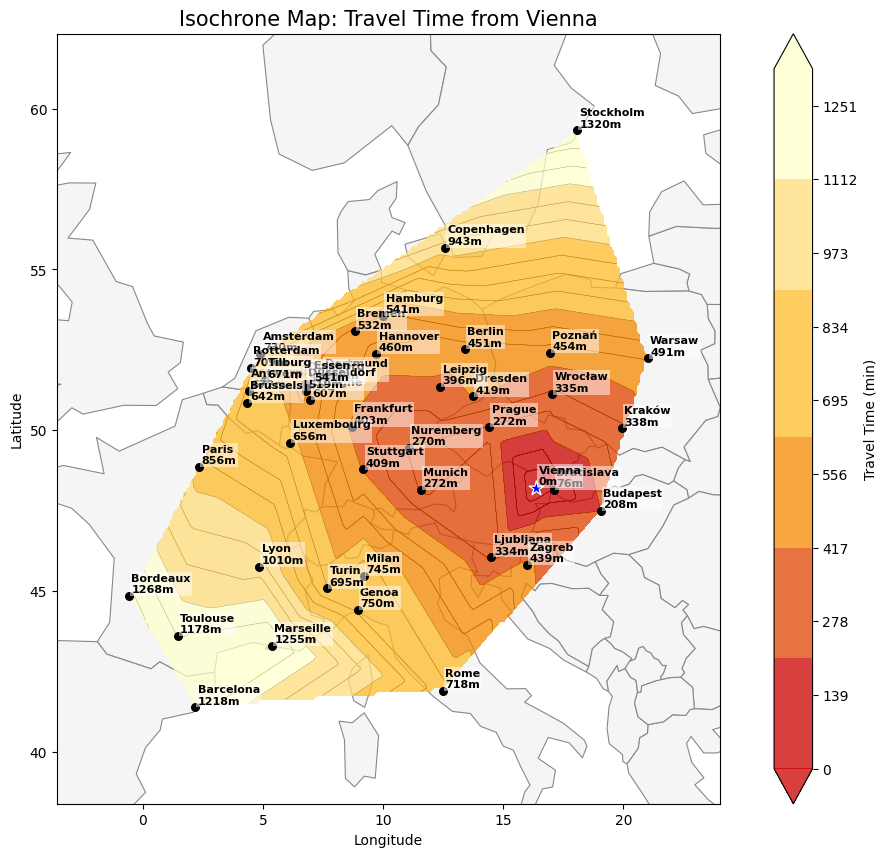

In [73]:
# Now let's use similar logic to visualize isochrones for only air and only rail transport
rail_transport_graph = create_transport_graph(rail_df_filtered)
rail_shortest_paths_df = calculate_shortest_paths(rail_df_filtered)
rail_centrality_graph, rail_centrality_df = analyze_network_centrality(rail_shortest_paths_df)
visualize_isochrones("Vienna", rail_centrality_graph, cities_coords_df)

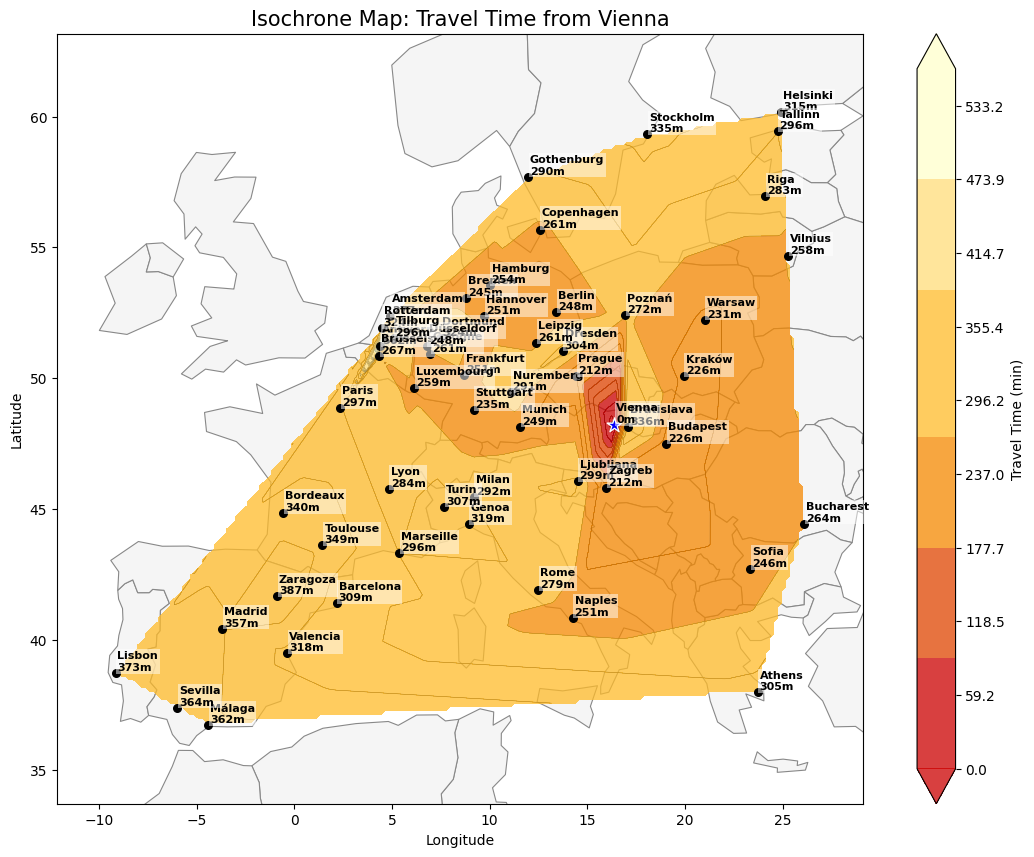

In [74]:
# same for air
air_transport_graph = create_transport_graph(air_df_filtered)
air_shortest_paths_df = calculate_shortest_paths(air_df_filtered)
air_centrality_graph, air_centrality_df = analyze_network_centrality(air_shortest_paths_df)
visualize_isochrones("Vienna", air_centrality_graph, cities_coords_df)

Check the best and worst cities with isochrones:
Duisburg vs Wroclaw

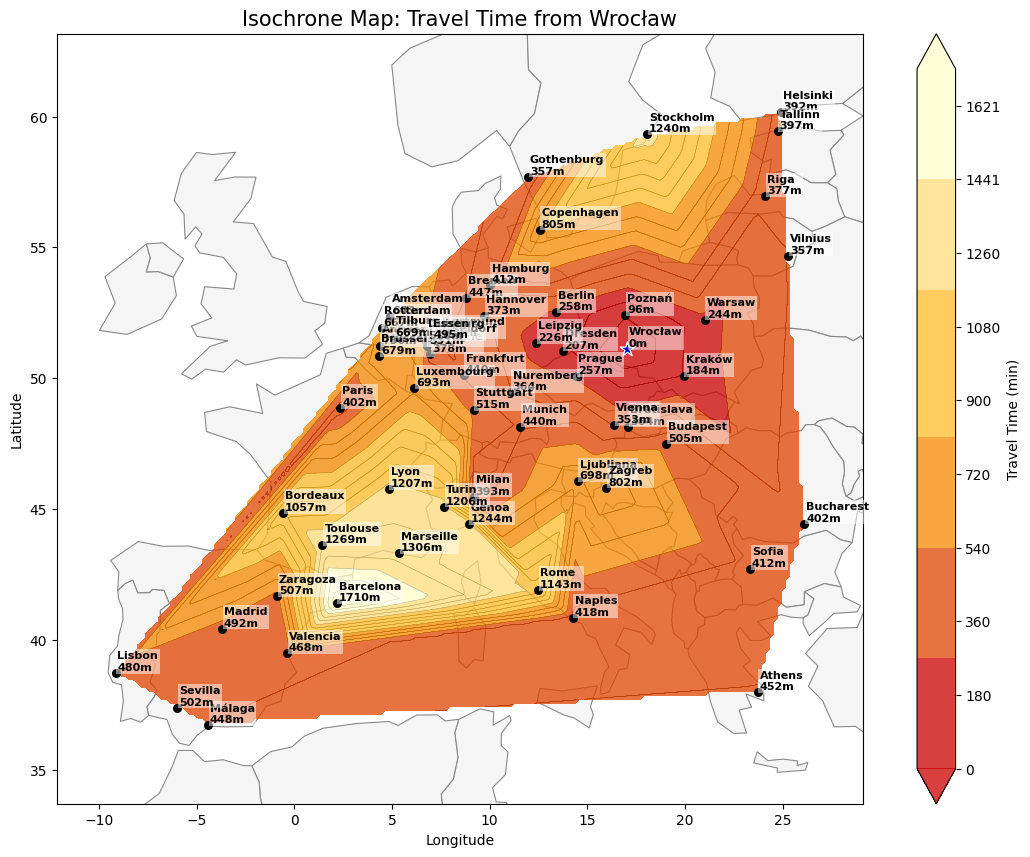

In [75]:
visualize_isochrones("Wrocław", centrality_graph, cities_coords_df)

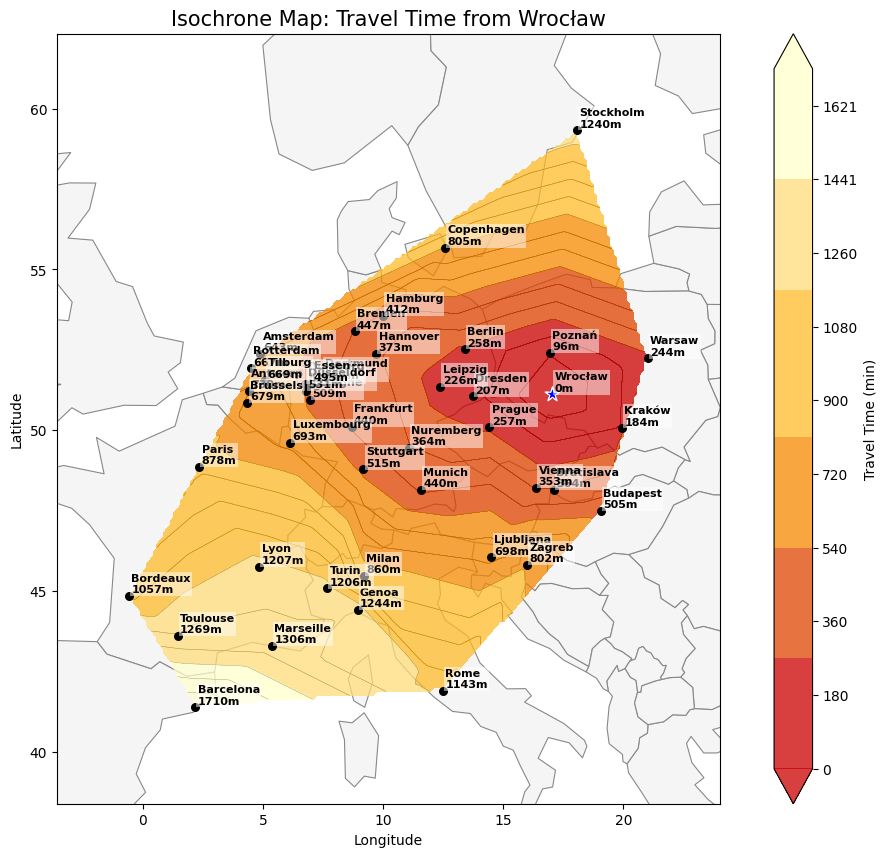

In [ ]:
visualize_isochrones("Wrocław", rail_centrality_graph, cities_coords_df)
# Wrocław doesn't have air connections

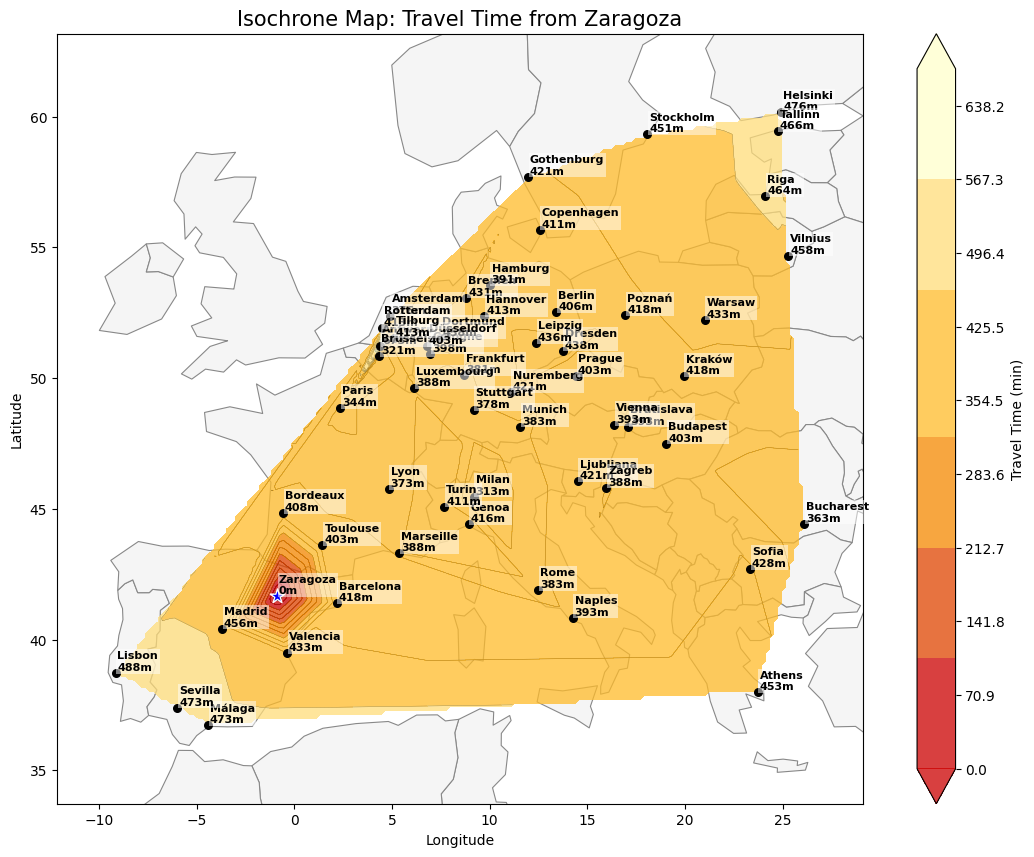

In [80]:
visualize_isochrones("Zaragoza", air_centrality_graph, cities_coords_df)

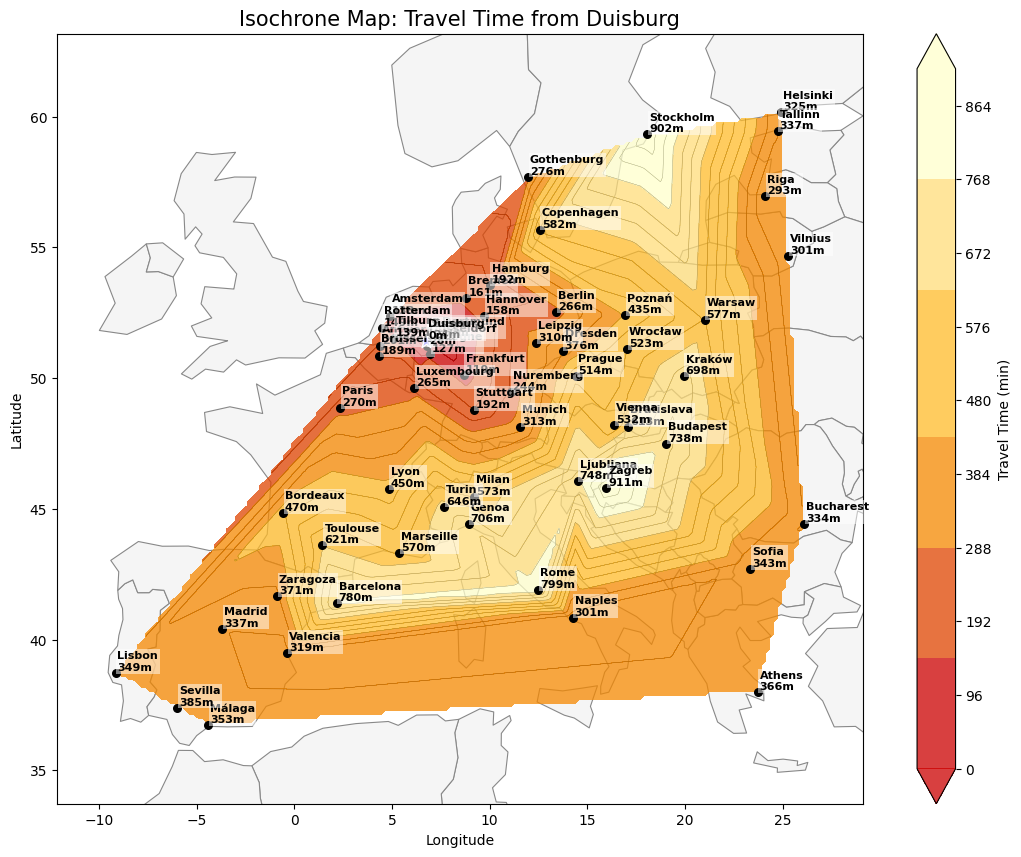

In [76]:
visualize_isochrones("Duisburg", centrality_graph, cities_coords_df)